In [2]:
"""
FFT analysis of turning angle data across 2500, 1000, and 250 fps recordings for turning and error angle.
One figure per trial, with all three fps overlaid on the same axes.
"""

import glob
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Found 7 trial(s): ['Trial2_180rpm', 'Trial2_200rpm', 'Trial3_180rpm', 'Trial4_400rpm', 'Trial5_180rpm', 'Trial5_400rpm', 'Trial7_400rpm']

===== Trial2_180rpm =====
2500 fps → dominant frequency: 7.35 Hz
1000 fps → dominant frequency: 3.66 Hz
250 fps → dominant frequency: 7.46 Hz


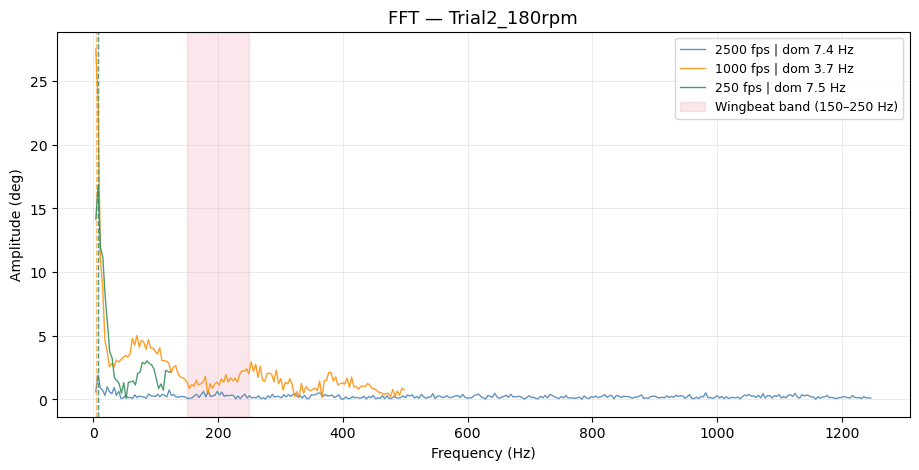


===== Trial2_200rpm =====
2500 fps → dominant frequency: 1140.94 Hz
1000 fps → dominant frequency: 16.13 Hz
250 fps → dominant frequency: 89.29 Hz


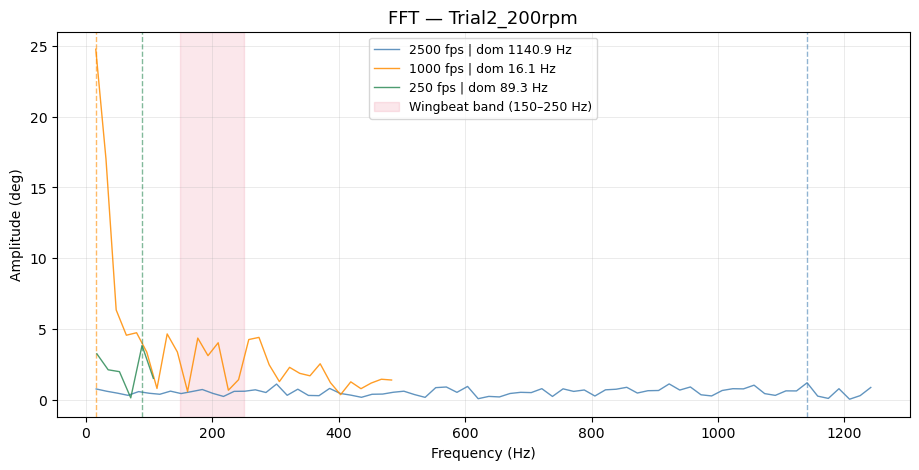


===== Trial3_180rpm =====
2500 fps → dominant frequency: 17.01 Hz
1000 fps → dominant frequency: 16.67 Hz
250 fps → dominant frequency: 17.86 Hz


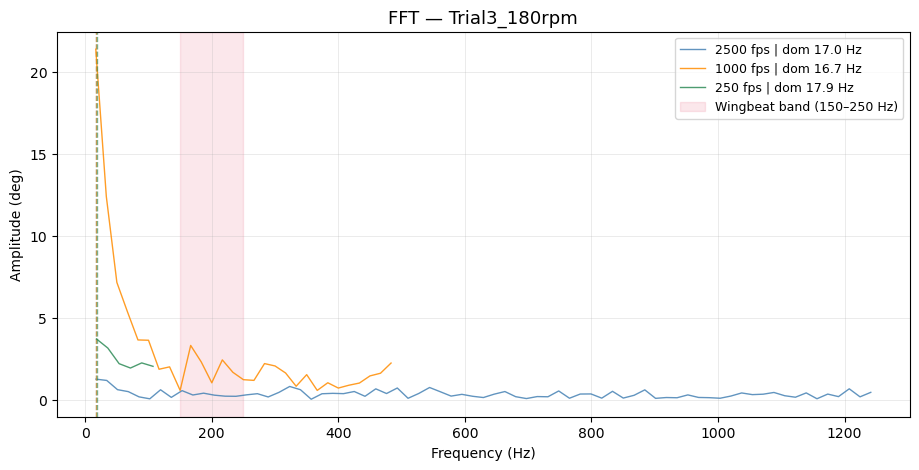


===== Trial4_400rpm =====
2500 fps → dominant frequency: 6.87 Hz
1000 fps → dominant frequency: 6.85 Hz
250 fps → dominant frequency: 7.14 Hz


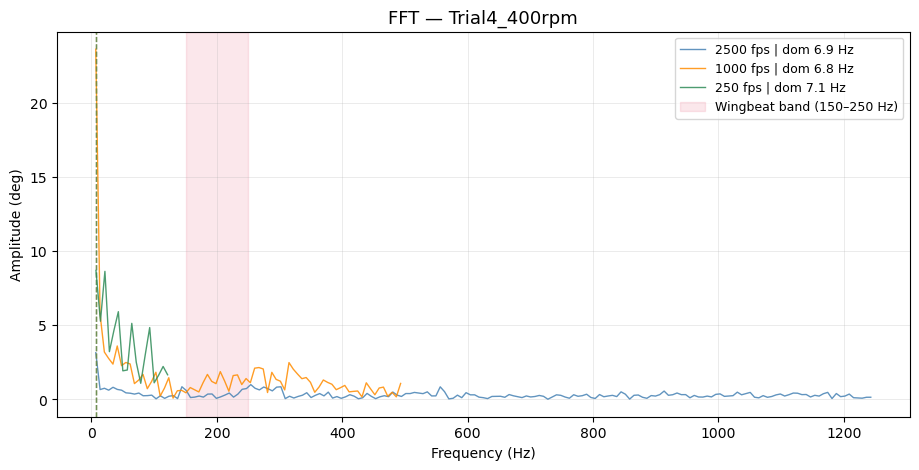


===== Trial5_180rpm =====
2500 fps → dominant frequency: 88.65 Hz
1000 fps → dominant frequency: 11.49 Hz
250 fps → dominant frequency: 5.95 Hz


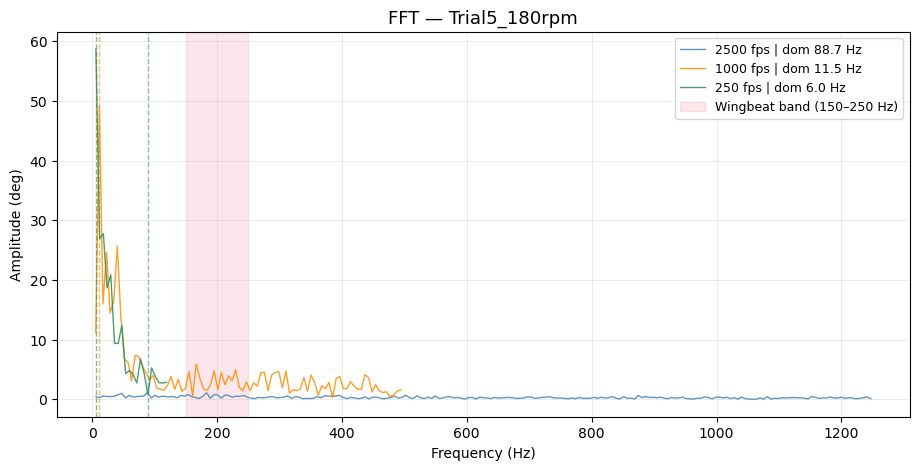


===== Trial5_400rpm =====
2500 fps → dominant frequency: 8.55 Hz
1000 fps → dominant frequency: 4.27 Hz
250 fps → dominant frequency: 100.88 Hz


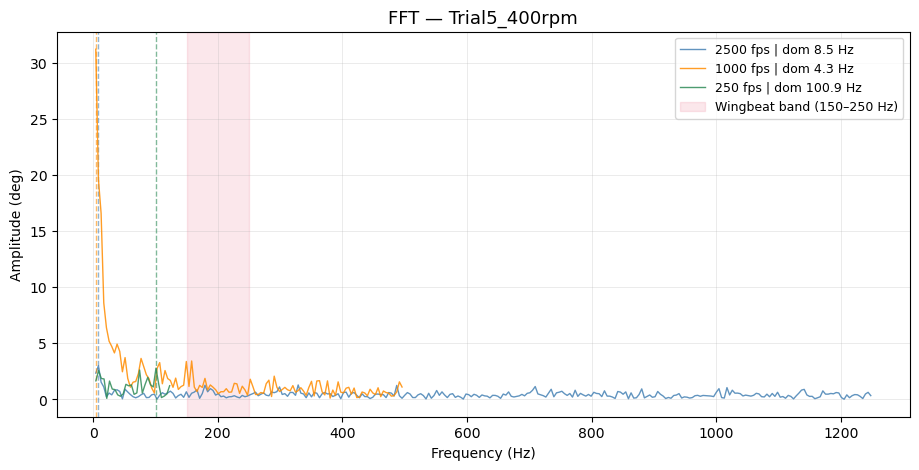


===== Trial7_400rpm =====
2500 fps → dominant frequency: 4.22 Hz
1000 fps → dominant frequency: 4.20 Hz
250 fps → dominant frequency: 17.24 Hz


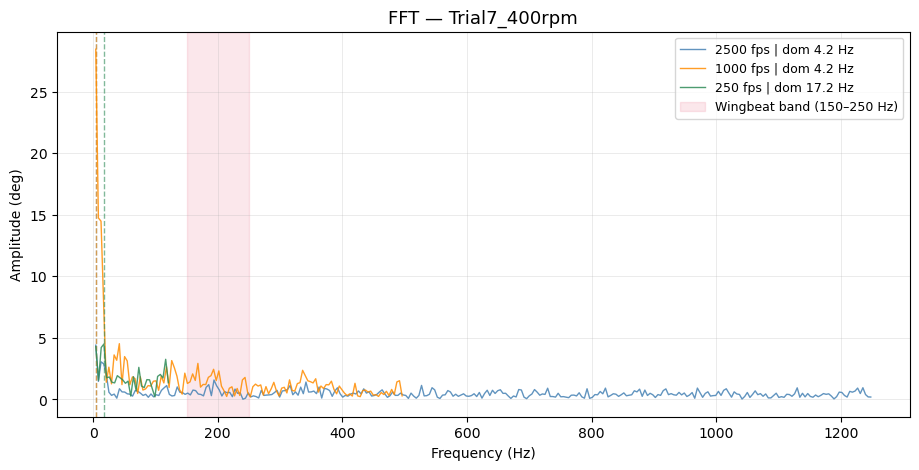

Done.


In [6]:

import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Configuration ──────────────────────────────────────────────────────────────

BASE_DIR = r"C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\Turning_angle"

SIGNAL_COL = "turning_angle_3d_deg"

WINGBEAT_LOW  = 150
WINGBEAT_HIGH = 250

PATTERNS = {
    2500: os.path.join(BASE_DIR, "Trimmed_2500fps",
                       "*_CENTER_TRIMMED_2500fps.csv"),
    1000: os.path.join(BASE_DIR,
                       "subsample_turning_angle_center-based_1000fps",
                       "*_1000fps_TRIMMED.csv"),
    250:  os.path.join(BASE_DIR,
                       "subsample_turning_angle_center-based",
                       "*_TURNING_ANGLE_TRIMMED.csv"),
}

COLORS = {2500: "steelblue", 1000: "darkorange", 250: "seagreen"}

# ── NEW FFT ───────────────────────────────────────────────

def half_fft(y, dt):
    y = y - np.mean(y)

    y_fft = np.fft.fft(y, norm='forward')
    freq = np.fft.fftfreq(len(y_fft), dt)

    # keep only positive frequencies
    fidx = freq >= 0
    freq = freq[fidx]
    y_fft = y_fft[fidx]

    # double non-DC components
    y_fft[1:] *= 2

    return y_fft, freq

def trial_id(filepath: str) -> str:
    base = os.path.basename(filepath)
    m = re.match(r"(Trial\d+_\d+rpm)", base, re.IGNORECASE)
    return m.group(1) if m else os.path.splitext(base)[0]

# ── Collect files ─────────────────────────────────────────────────────────────

trials = {}

for fps, pattern in PATTERNS.items():
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No files matched for {fps} fps: {pattern}")
    for fp in files:
        tid = trial_id(fp)
        trials.setdefault(tid, {})[fps] = fp

if not trials:
    raise FileNotFoundError("No CSV files found.")

print(f"Found {len(trials)} trial(s): {list(trials.keys())}")

# ── Output dir ────────────────────────────────────────────────────────────────

os.makedirs("fft_output", exist_ok=True)

# ── Main loop ─────────────────────────────────────────────────────────────────

for tid, fps_files in sorted(trials.items()):

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(f"FFT — {tid}", fontsize=13)

    print(f"\n===== {tid} =====")

    for fps in sorted(fps_files, reverse=True):
        fp = fps_files[fps]
        df = pd.read_csv(fp)

        if SIGNAL_COL not in df.columns:
            print(f"[warn] '{SIGNAL_COL}' not in {fp} — skipping")
            continue

        signal = df[SIGNAL_COL].dropna().values

        # sampling interval
        dt = 1.0 / fps

        # FFT
        y_fft, freqs = half_fft(signal, dt)
        amp = np.abs(y_fft)

        # dominant frequency
        peak_idx = np.argmax(amp[1:]) + 1  # skip DC
        peak_f = freqs[peak_idx]

        print(f"{fps} fps → dominant frequency: {peak_f:.2f} Hz")

        # plot
        ax.plot(freqs[1:], amp[1:],
                color=COLORS[fps],
                lw=1.0,
                alpha=0.85,
                label=f"{fps} fps | dom {peak_f:.1f} Hz")

        ax.axvline(peak_f,
                   color=COLORS[fps],
                   ls="--",
                   lw=1.0,
                   alpha=0.6)

    # wingbeat band
    ax.axvspan(WINGBEAT_LOW, WINGBEAT_HIGH,
               color="crimson",
               alpha=0.1,
               label="Wingbeat band (150–250 Hz)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Amplitude (deg)")
    ax.grid(True, lw=0.4, alpha=0.45)
    ax.legend(fontsize=9)

    plt.show()

print("Done.")

Found 7 trials

===== Trial2_180rpm =====
2500 fps → dominant frequency: 6.53 Hz
1000 fps → dominant frequency: 6.56 Hz
250 fps → dominant frequency: 9.74 Hz


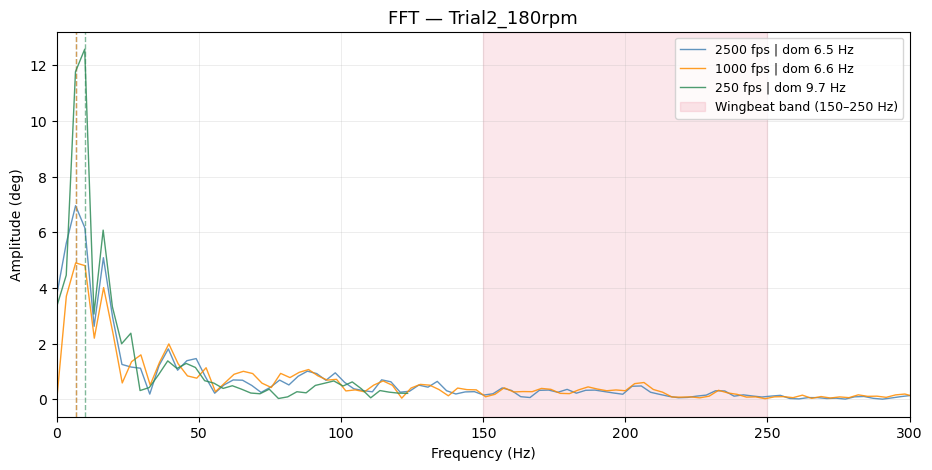


===== Trial2_200rpm =====
2500 fps → dominant frequency: 10.92 Hz
1000 fps → dominant frequency: 21.98 Hz
250 fps → dominant frequency: 32.61 Hz


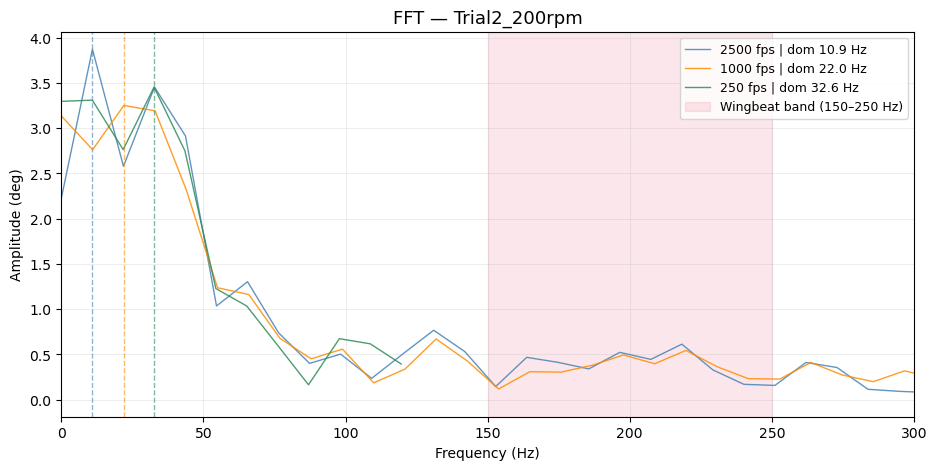


===== Trial3_180rpm =====
2500 fps → dominant frequency: 0.00 Hz
1000 fps → dominant frequency: 0.00 Hz
250 fps → dominant frequency: 0.00 Hz


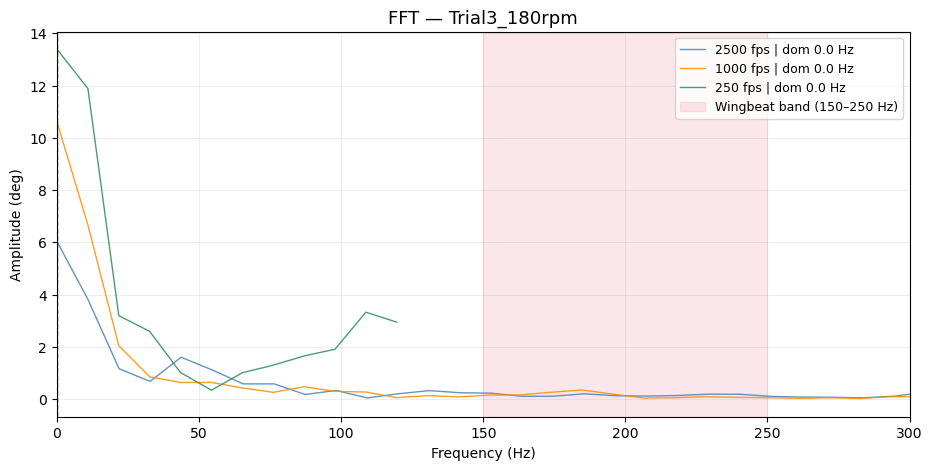


===== Trial4_400rpm =====
2500 fps → dominant frequency: 5.61 Hz
1000 fps → dominant frequency: 5.62 Hz
250 fps → dominant frequency: 5.56 Hz


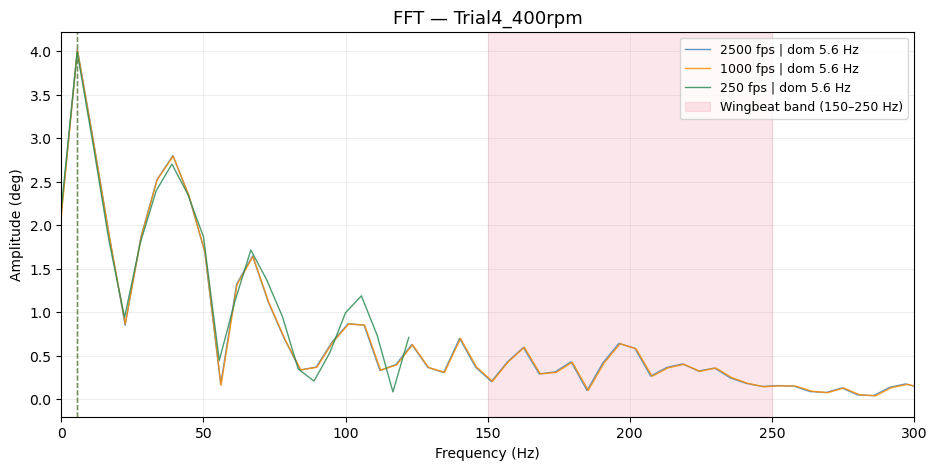


===== Trial5_180rpm =====
2500 fps → dominant frequency: 19.57 Hz
1000 fps → dominant frequency: 19.70 Hz
250 fps → dominant frequency: 4.81 Hz


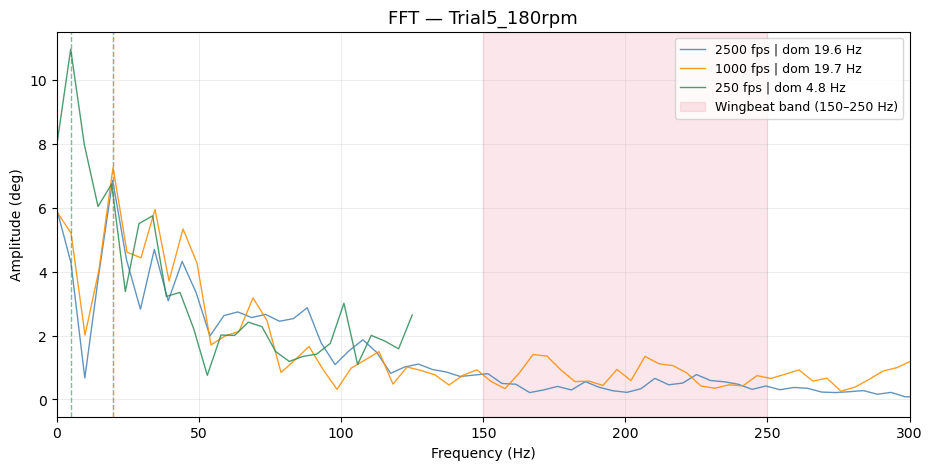


===== Trial5_400rpm =====
2500 fps → dominant frequency: 7.50 Hz
1000 fps → dominant frequency: 7.52 Hz
250 fps → dominant frequency: 7.46 Hz


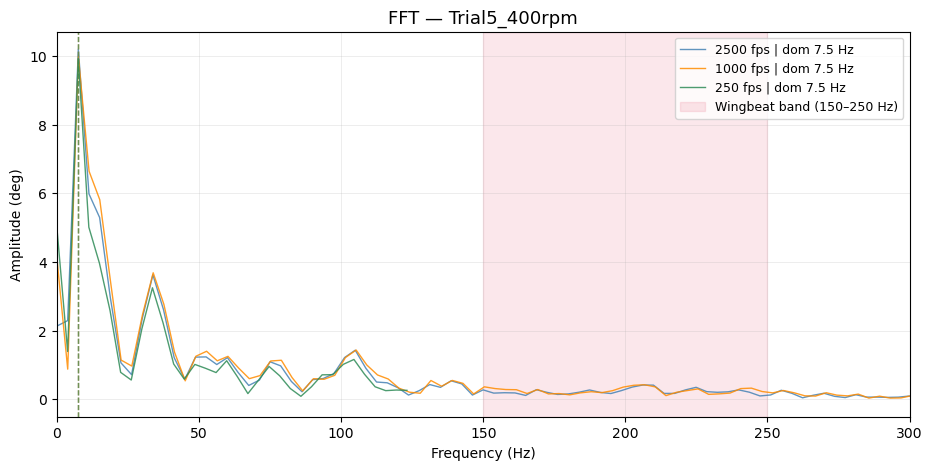


===== Trial7_400rpm =====
2500 fps → dominant frequency: 3.70 Hz
1000 fps → dominant frequency: 3.70 Hz
250 fps → dominant frequency: 3.68 Hz


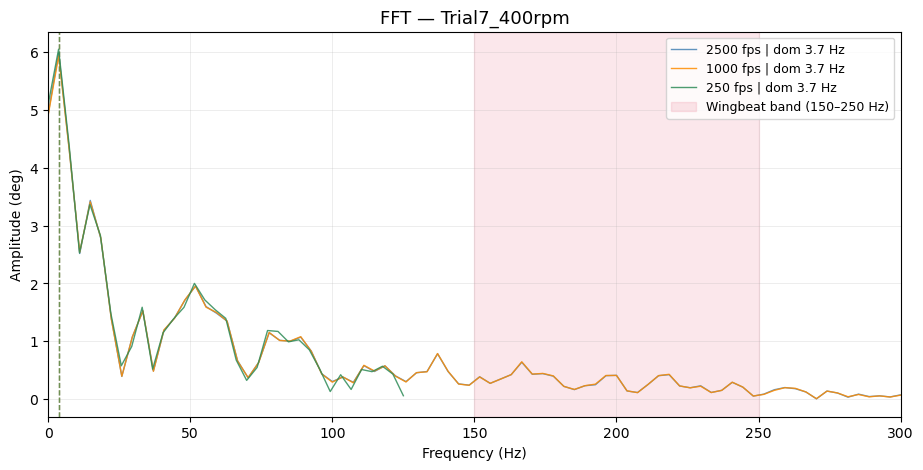


Done.


In [8]:


# ── Configuration ──────────────────────────────────────────────────────────────

BASE_DIR = r"C:\Users\munpa\OneDrive - Shiv Nadar Institution of Eminence\MuscaChase\dataFolders\MuscaChasingBeads\ErrorAngle_DistFromBead"

SIGNAL_COL = "error_angle_head_deg"

WINGBEAT_LOW  = 150
WINGBEAT_HIGH = 250

PATTERNS = {
    2500: os.path.join(BASE_DIR, "*_CHASE_METRICS.csv"),
    1000: os.path.join(BASE_DIR,
                       "ErrorAngle_DistFromBead_Subsampled_1000fps",
                       "*_CHASE_METRICS_1000fps.csv"),
    250:  os.path.join(BASE_DIR,
                       "ErrorAngle_DistFromBead_Subsampled",
                       "*_CHASE_METRICS.csv"),
}

COLORS = {2500: "steelblue", 1000: "darkorange", 250: "seagreen"}

# ── FFT ───────────────────────────────────────────────────────────────────────

def compute_fft(signal: np.ndarray, fs: float):
    N = len(signal)

    # unwrap angle
    signal = np.deg2rad(signal)
    signal = np.unwrap(signal)
    signal = np.rad2deg(signal)

    signal = signal - np.mean(signal)
    win = np.hanning(N)

    fft_vals = np.fft.rfft(signal * win)
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    amp = (2.0 / N) * np.abs(fft_vals)

    return freqs, amp

def trial_id(filepath: str) -> str:
    base = os.path.basename(filepath)
    m = re.match(r"(Trial\d+_\d+rpm)", base, re.IGNORECASE)
    return m.group(1) if m else os.path.splitext(base)[0]

# ── Collect files ─────────────────────────────────────────────────────────────

trials = {}

for fps, pattern in PATTERNS.items():
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[warn] No files for {fps} fps: {pattern}")
    for fp in files:
        tid = trial_id(fp)
        trials.setdefault(tid, {})[fps] = fp

if not trials:
    raise FileNotFoundError("No CSV files found.")

print(f"Found {len(trials)} trials")

# ── Output dir ────────────────────────────────────────────────────────────────

os.makedirs("fft_output", exist_ok=True)

# ── Main loop ─────────────────────────────────────────────────────────────────

for tid, fps_files in sorted(trials.items()):

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(f"FFT — {tid}", fontsize=13)

    print(f"\n===== {tid} =====")

    for fps in sorted(fps_files, reverse=True):
        fp = fps_files[fps]
        df = pd.read_csv(fp)

        if SIGNAL_COL not in df.columns:
            print(f"[warn] Missing {SIGNAL_COL} in {fp}")
            continue

        signal = df[SIGNAL_COL].dropna().values
        fs_actual = fps

        freqs, amp = compute_fft(signal, fs_actual)

        # dominant frequency
        peak_idx = np.argmax(amp)
        peak_f   = freqs[peak_idx]

        print(f"{fps} fps → dominant frequency: {peak_f:.2f} Hz")

        # plot
        ax.plot(freqs, amp, color=COLORS[fps], lw=1.0, alpha=0.85,
                label=f"{fps} fps | dom {peak_f:.1f} Hz")

        ax.axvline(peak_f, color=COLORS[fps], ls="--", lw=1.0, alpha=0.6)

    # wingbeat band (just visual reference)
    ax.axvspan(WINGBEAT_LOW, WINGBEAT_HIGH,
               color="crimson", alpha=0.1,
               label="Wingbeat band (150–250 Hz)")

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Amplitude (deg)")
    ax.set_xlim(0, 300)
    ax.grid(True, lw=0.4, alpha=0.4)
    ax.legend(fontsize=9)

    # fig.tight_layout()

    # out_path = os.path.join("fft_output", f"{tid}_fft.png")
    # fig.savefig(out_path, dpi=150)
    # print(f"Saved: {out_path}")

    plt.show()

print("\nDone.")